# EDA & Business Insights — Consumer Complaints Dataset

This analysis is built on the preprocessed data (`cleaned_complaints.csv`) — **124,620 complaints** spread across 5 financial product categories (Credit Reporting, Debt Collection, Mortgages & Loans, Credit Card, Retail Banking).

Goal: surface business insights that support concrete decisions (resource allocation, process improvement, risk management) in a clear, presentation-ready way.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['figure.dpi'] = 110

PALETTE = {
    'credit_reporting':    '#1D3557',
    'debt_collection':     '#457B9D',
    'mortgages_and_loans': '#2A9D8F',
    'credit_card':         '#E9C46A',
    'retail_banking':      '#E76F51',
}
LABELS = {
    'credit_reporting':    'Credit Reporting',
    'debt_collection':     'Debt Collection',
    'mortgages_and_loans': 'Mortgages & Loans',
    'credit_card':         'Credit Card',
    'retail_banking':      'Retail Banking',
}

df = pd.read_csv('../data/processed/cleaned_complaints.csv')
df['narrative_len'] = df['narrative'].str.split().str.len()
order = df['product'].value_counts().index.tolist()
print(df.shape)
df.head(3)

(124620, 3)


,product,narrative,narrative_len
0,credit_card,purchase order day shipping amount receive pro...,230
1,credit_card,forwarded message date tue subject please inve...,132
2,retail_banking,forwarded message cc sent friday pdt subject f...,173


## 1️⃣ Insight #1 — Credit Reporting is the real center of gravity (45% of all complaints)

**Finding:** The `credit_reporting` category alone accounts for **45.2%** of all complaints (56,276 complaints) — more than double the next largest category (`debt_collection` at 16.9%).

**Why it matters for the business:** Any investment in improving customer experience or speeding up complaint handling should start here first — priority is not evenly distributed across departments.

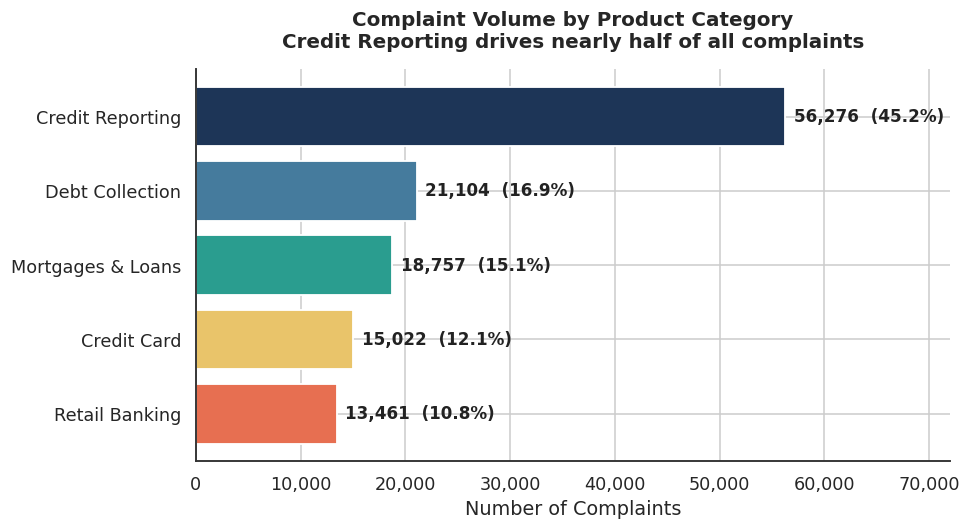

In [2]:
counts = df['product'].value_counts().loc[order]
pct = (counts / counts.sum() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh([LABELS[p] for p in order], counts.values,
               color=[PALETTE[p] for p in order], edgecolor='white', linewidth=1.2)

for bar, c, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_width() + 800, bar.get_y() + bar.get_height()/2,
            f"{c:,}  ({p:.1f}%)", va='center', fontsize=11, fontweight='bold', color='#222')

ax.invert_yaxis()
ax.set_xlabel('Number of Complaints')
ax.set_title('Complaint Volume by Product Category\nCredit Reporting drives nearly half of all complaints', fontsize=13, fontweight='bold', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, counts.max()*1.28)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('insight1_volume.png', bbox_inches='tight')
plt.show()

## 2️⃣ Insight #2 — Volume isn't complexity: Mortgages are smaller in volume but far more complex

**Finding:** `mortgages_and_loans` complaints are the longest on average (**118 words**), despite making up only 15% of total volume. Meanwhile `credit_reporting` (45% of volume) has the shortest complaints on average (**74 words**).

**Why it matters for the business:** Handling strategy needs to differ by category — `credit_reporting` needs **high-throughput, fast triage**, while `mortgages_and_loans` needs **experienced specialists able to handle long, complex cases**, even though its volume is lower.

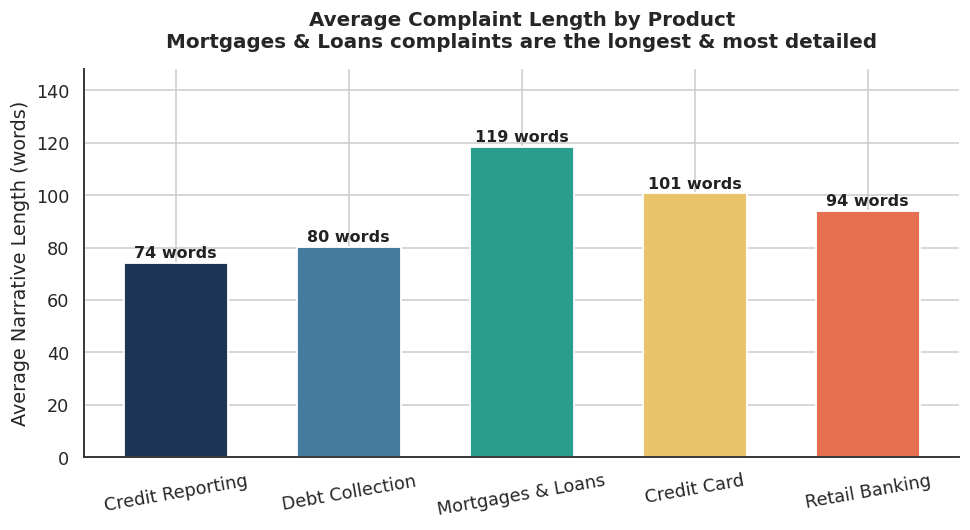

In [3]:
len_stats = df.groupby('product')['narrative_len'].mean().loc[order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([LABELS[p] for p in order], len_stats.values,
              color=[PALETTE[p] for p in order], edgecolor='white', linewidth=1.2, width=0.6)

for bar, v in zip(bars, len_stats.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v:.0f} words",
            ha='center', fontsize=10.5, fontweight='bold', color='#222')

ax.set_ylabel('Average Narrative Length (words)')
ax.set_title('Average Complaint Length by Product\nMortgages & Loans complaints are the longest & most detailed', fontsize=13, fontweight='bold', pad=14)
ax.set_ylim(0, len_stats.max()*1.25)
plt.xticks(rotation=10)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('insight2_length.png', bbox_inches='tight')
plt.show()

## 3️⃣ Insight #3 — Dispute resolution is the core driver behind Credit Reporting & Debt Collection complaints

**Finding:** The word "dispute" appears in **30.8%** of `credit_reporting` complaints and **24.3%** of `debt_collection` complaints — far higher than any other category. Similarly, "identity theft" is concentrated in the same two categories (11.4% and 7.1%).

**Why it matters for the business:** These two categories share the same root problem (data accuracy + verification/dispute processes), so they could be handled by a unified team or shared workflow to speed up dispute resolution, instead of each department working in isolation.

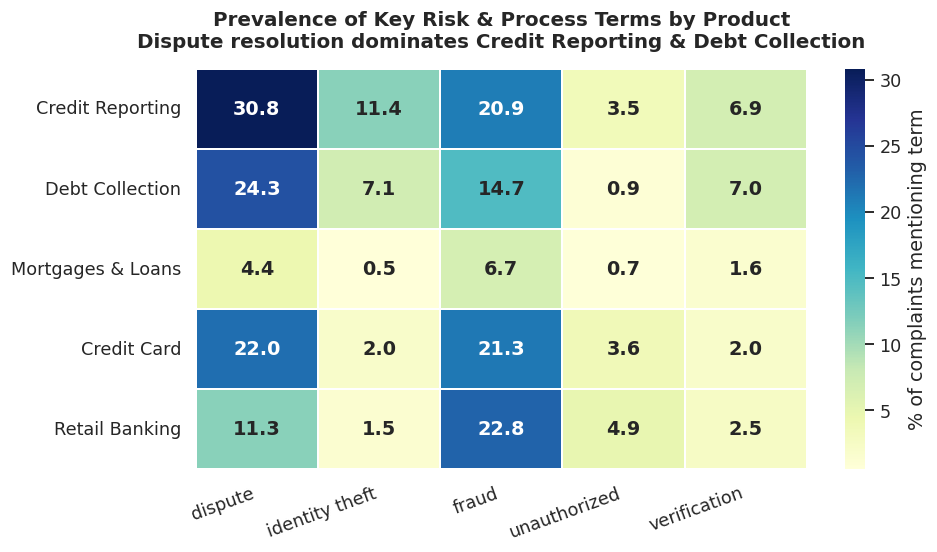

In [4]:
keywords = ['dispute', 'identity theft', 'fraud', 'unauthorized', 'verification']
heat = pd.DataFrame({
    kw: df['narrative'].str.contains(kw, case=False, regex=False).groupby(df['product']).mean()*100
    for kw in keywords
}).loc[order]
heat.index = [LABELS[p] for p in order]

fig, ax = plt.subplots(figsize=(9, 5.2))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=1.2, linecolor='white',
            cbar_kws={'label': '% of complaints mentioning term'}, ax=ax, annot_kws={'fontweight':'bold'})
ax.set_title('Prevalence of Key Risk & Process Terms by Product\nDispute resolution dominates Credit Reporting & Debt Collection', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('insight3_heatmap.png', bbox_inches='tight')
plt.show()

## 4️⃣ Insight #4 — A phone customer-service gap: absent in Credit Reporting, dominant everywhere else

**Finding:** Words like "called" and "told" (signaling a phone interaction with customer service) are heavily present in `credit_card` (37.7%/33%), `mortgages_and_loans` (34.5%/37.3%), and `retail_banking` (31.5%/33.1%) — but almost absent in `credit_reporting` (only 11.4%).

**Why it matters for the business:** The majority of Credit Card/Mortgages/Retail Banking complaints stem from **a poor call or communication experience** (conflicting promises, wrong information given by phone), while Credit Reporting complaints stem from **data/process issues, not human interaction**. Fixing the first problem needs agent training and call-quality improvement; fixing the second needs systems improvement.

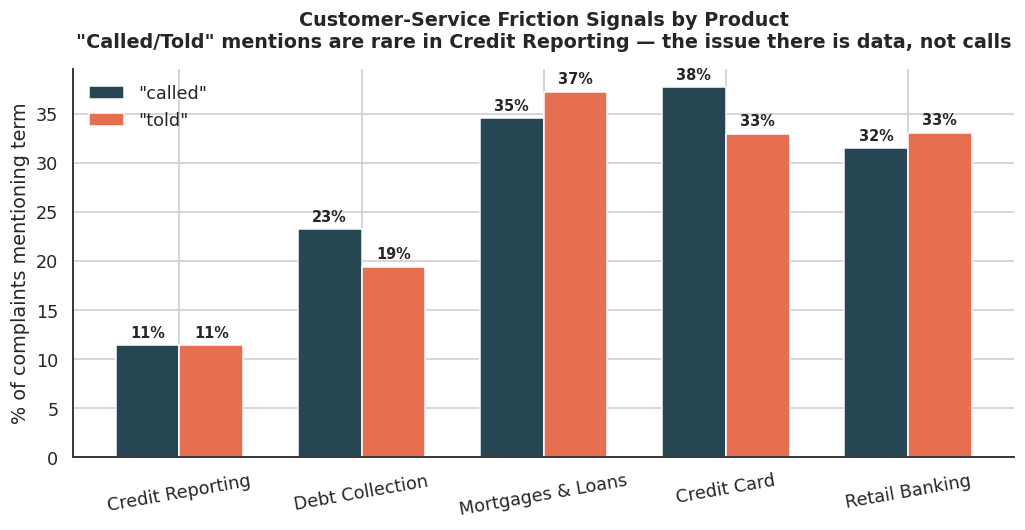

In [5]:
cs_terms = ['called', 'told']
cs = pd.DataFrame({
    t: df['narrative'].str.contains(t, case=False, regex=False).groupby(df['product']).mean()*100
    for t in cs_terms
}).loc[order]

x = np.arange(len(order))
width = 0.35
fig, ax = plt.subplots(figsize=(9.5, 5))
b1 = ax.bar(x - width/2, cs['called'], width, label='"called"', color='#264653', edgecolor='white')
b2 = ax.bar(x + width/2, cs['told'], width, label='"told"', color='#E76F51', edgecolor='white')

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.8, f"{h:.0f}%", ha='center', fontsize=9.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([LABELS[p] for p in order], rotation=10)
ax.set_ylabel('% of complaints mentioning term')
ax.set_title('Customer-Service Friction Signals by Product\n"Called/Told" mentions are rare in Credit Reporting — the issue there is data, not calls', fontsize=12.5, fontweight='bold', pad=14)
ax.legend(frameon=False)
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('insight4_cs.png', bbox_inches='tight')
plt.show()

## 5️⃣ Insight #5 — Strategic map: Volume vs. Complexity vs. Dispute Intensity

**Finding:** Combining three metrics (complaint volume, average complaint length, and % mentioning "dispute") shows that each category needs a fundamentally different strategy:
- **Credit Reporting**: huge volume + very high dispute rate + short complaints → **automation and self-service dispute resolution**.
- **Mortgages & Loans**: small volume + very long complaints + low dispute rate → **experienced specialists, high-touch handling**.
- **Debt Collection**: moderate volume + high dispute rate → **legal/compliance review of collection practices**.

**Why it matters for the business:** Instead of distributing resources evenly across all categories, this map shows that each one needs a different type of investment — technology, human expertise, or compliance.

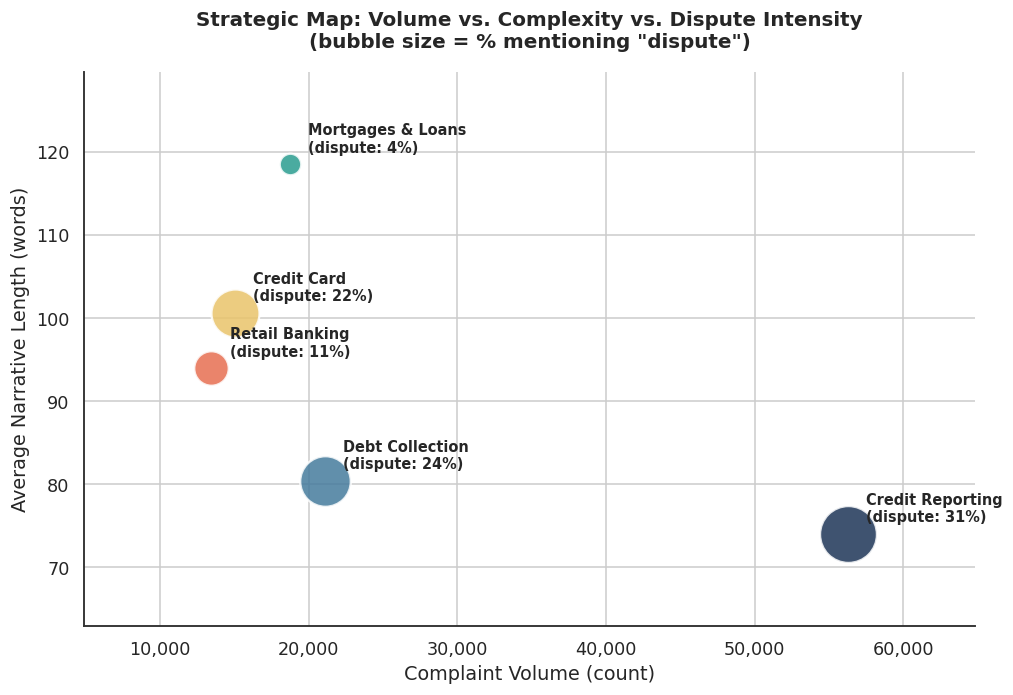

In [6]:
summary = pd.DataFrame({
    'volume': df['product'].value_counts(),
    'avg_length': df.groupby('product')['narrative_len'].mean(),
    'dispute_pct': df['narrative'].str.contains('dispute', case=False, regex=False).groupby(df['product']).mean()*100,
}).loc[order]

fig, ax = plt.subplots(figsize=(9.5, 6.5))

for p in order:
    ax.scatter(summary.loc[p, 'volume'], summary.loc[p, 'avg_length'],
               s=summary.loc[p, 'dispute_pct']*45, color=PALETTE[p], alpha=0.85,
               edgecolor='white', linewidth=1.5, zorder=3)
    ax.annotate(f"{LABELS[p]}\n(dispute: {summary.loc[p,'dispute_pct']:.0f}%)",
                (summary.loc[p, 'volume'], summary.loc[p, 'avg_length']),
                textcoords="offset points", xytext=(12, 8), fontsize=9.5, fontweight='bold')

ax.set_xlabel('Complaint Volume (count)')
ax.set_ylabel('Average Narrative Length (words)')
ax.set_title('Strategic Map: Volume vs. Complexity vs. Dispute Intensity\n(bubble size = % mentioning "dispute")', fontsize=13, fontweight='bold', pad=16)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for spine in ['top','right']:
    ax.spines[spine].set_visible(False)
ax.margins(x=0.2, y=0.25)
plt.tight_layout()
plt.savefig('insight5_map.png', bbox_inches='tight')
plt.show()

## 📌 Executive Summary — The 5 Insights

| # | Insight | Recommendation |
|---|---------|-----------------|
| 1 | Credit Reporting = 45% of all complaints | Top priority for resource allocation |
| 2 | Mortgages complaints are longer & more complex despite lower volume | Dedicated specialist team for complex cases |
| 3 | Dispute / Identity theft concentrated in Reporting & Collections | Unified workflow to speed up dispute resolution |
| 4 | Phone communication issues are absent from Reporting but dominant elsewhere | Train call-center teams rather than rebuild systems |
| 5 | Each category needs a different strategy (automation / human expertise / compliance) | Tailored investment map per department |
